In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import sklearn
import seaborn as sns

In [3]:
df=pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


EDA


In [114]:
df.shape

(1338, 7)

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [116]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [117]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

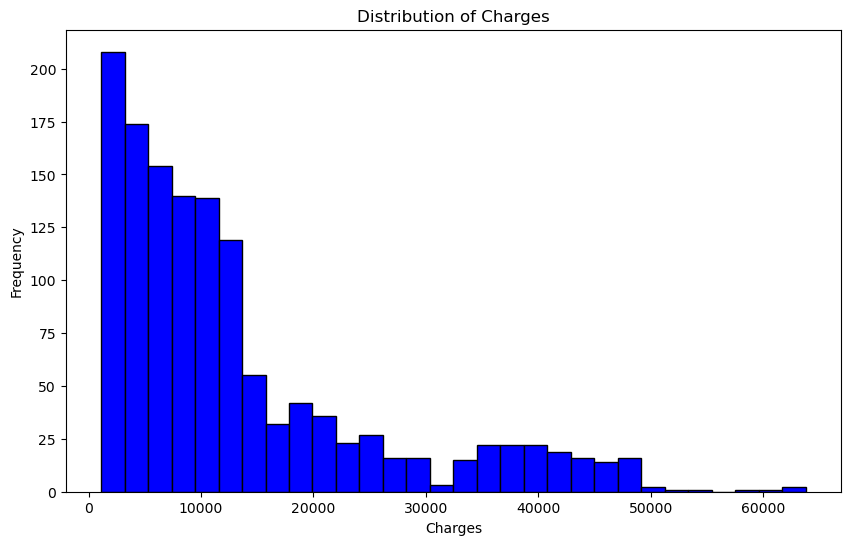

In [118]:
plt.figure(figsize=(10,6))
plt.hist(df['charges'], bins=30, color='blue', edgecolor='black')   
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

In [119]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [120]:
numeric_columns=['age', 'bmi', 'children', 'charges']

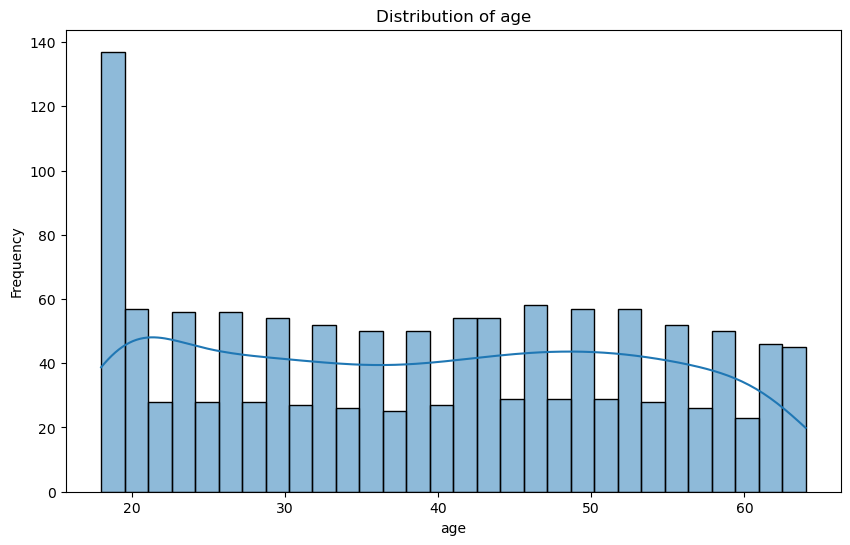

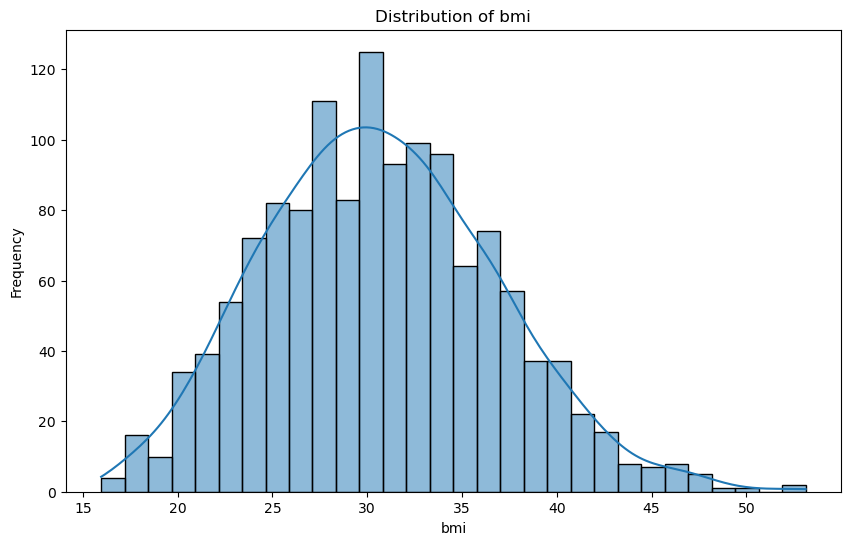

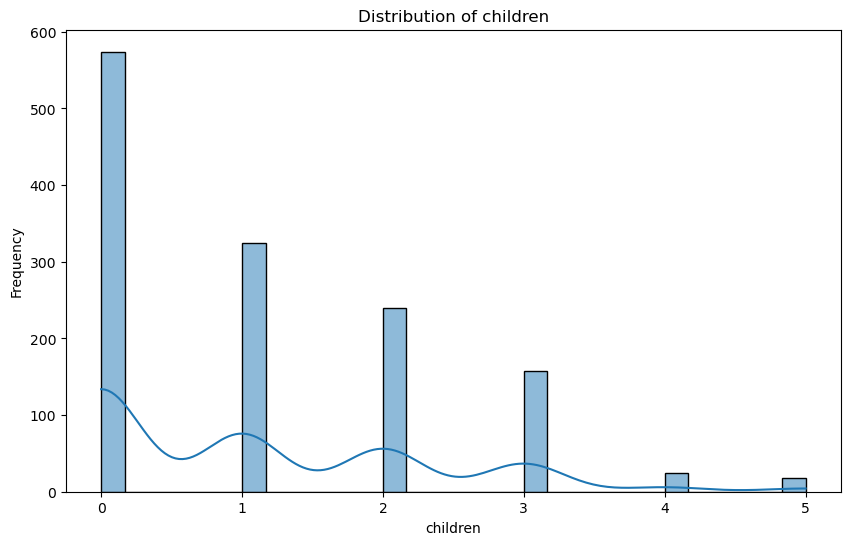

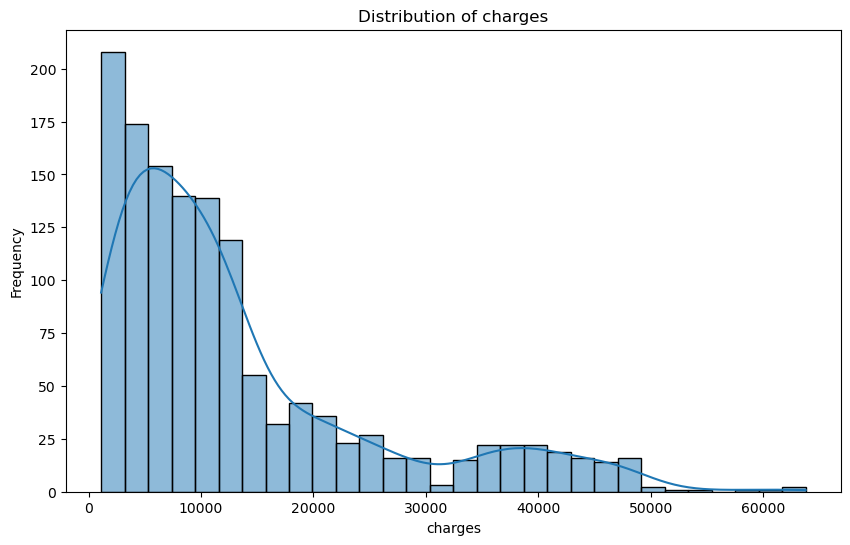

In [121]:
for col in numeric_columns:
    plt.figure(figsize=(10,6))
    sns.histplot(x=df[col],kde=True, bins=30, )
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

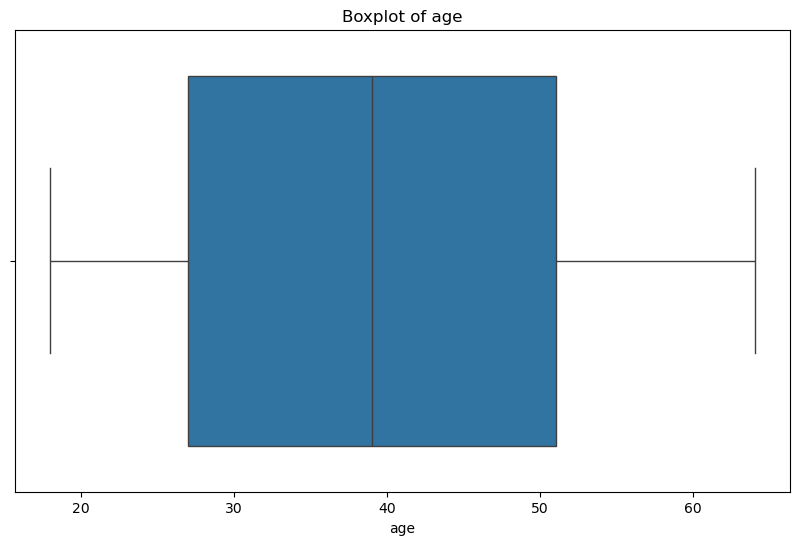

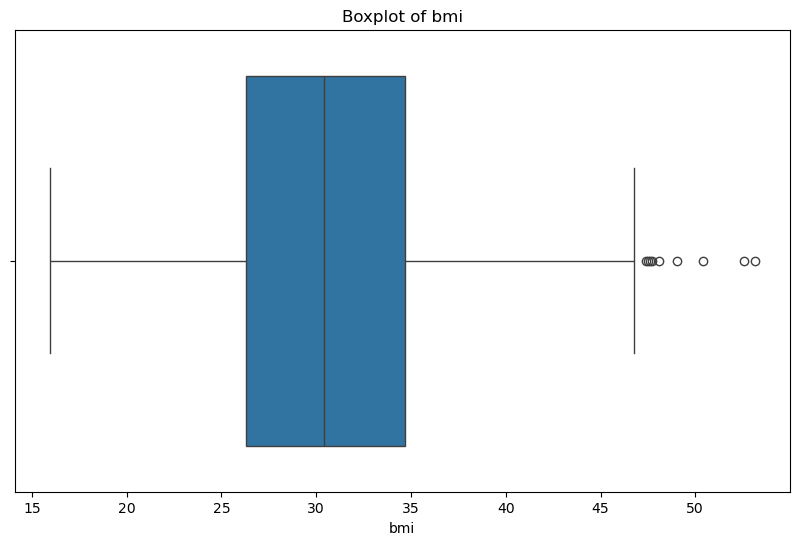

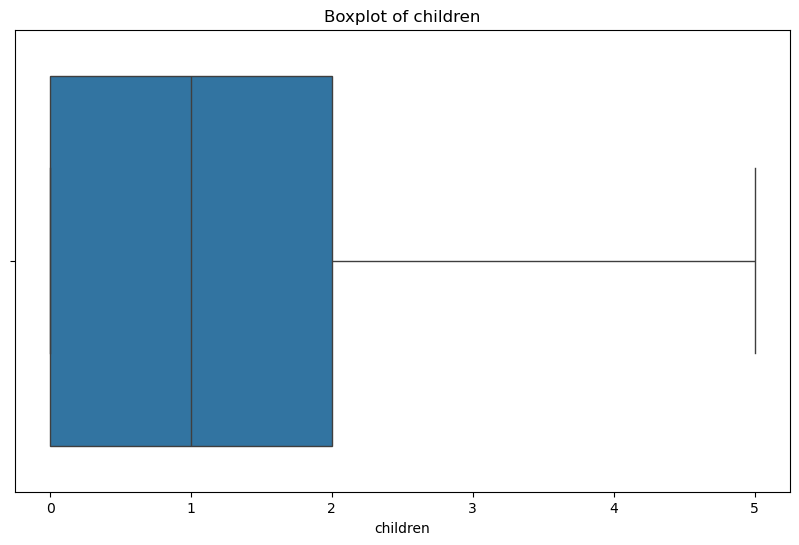

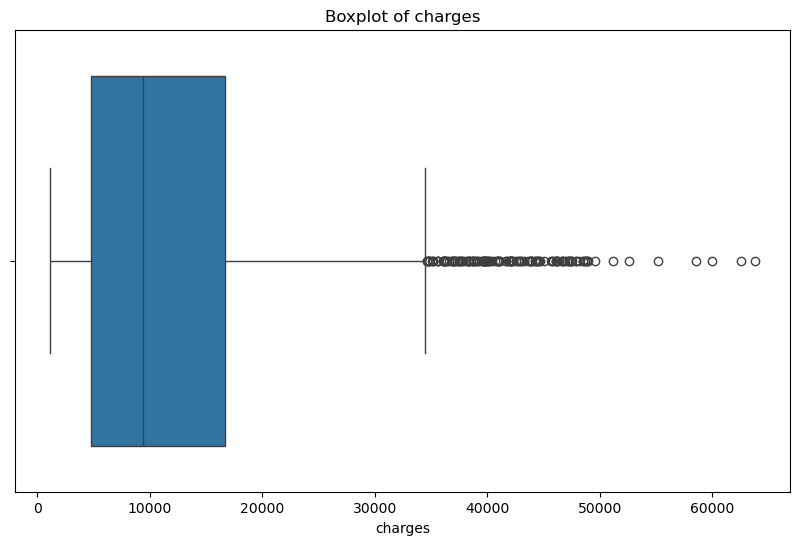

In [122]:
for col in numeric_columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()



<Axes: >

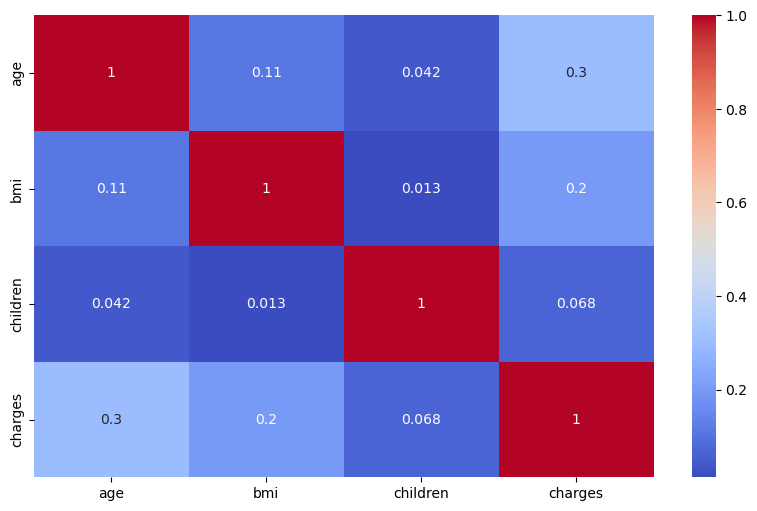

In [123]:
plt.figure(figsize=(10,6))  
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

DATA CLEANING AND PRE-PROCESSING


In [124]:
df_cleaned=df.copy()
df_cleaned.shape
print(type(df_cleaned))


<class 'pandas.core.frame.DataFrame'>


In [125]:
df_cleaned.drop_duplicates(inplace = True)
df_cleaned.shape

(1337, 7)

In [126]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [127]:
df_cleaned.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [128]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [129]:
df_cleaned["sex"].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [130]:
df_cleaned["sex"]=df_cleaned["sex"].map({"male":0,"female":1} )

In [131]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [132]:
df_cleaned["smoker"].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [133]:
df_cleaned["smoker"]=df_cleaned["smoker"].map({"yes":1,"no":1})

In [134]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,northwest,10600.54830
1334,18,1,31.920,0,1,northeast,2205.98080
1335,18,1,36.850,0,1,southeast,1629.83350
1336,21,1,25.800,0,1,southwest,2007.94500


In [135]:
df_cleaned.rename(columns={"sex":"is_female","smoker":"is_smoker"}, inplace=True)

In [136]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,northwest,10600.54830
1334,18,1,31.920,0,1,northeast,2205.98080
1335,18,1,36.850,0,1,southeast,1629.83350
1336,21,1,25.800,0,1,southwest,2007.94500


In [137]:
df_cleaned["region"].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [138]:
df_cleaned["region"].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [139]:
df_cleaned=pd.get_dummies(df_cleaned,columns=["region"],drop_first=True)   

In [140]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,1,1725.55230,False,True,False
2,28,0,33.000,3,1,4449.46200,False,True,False
3,33,0,22.705,0,1,21984.47061,True,False,False
4,32,0,28.880,0,1,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,10600.54830,True,False,False
1334,18,1,31.920,0,1,2205.98080,False,False,False
1335,18,1,36.850,0,1,1629.83350,False,True,False
1336,21,1,25.800,0,1,2007.94500,False,False,True


In [141]:
df_cleaned.astype("int")

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,1,1725,0,1,0
2,28,0,33,3,1,4449,0,1,0
3,33,0,22,0,1,21984,1,0,0
4,32,0,28,0,1,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,1,0,0
1334,18,1,31,0,1,2205,0,0,0
1335,18,1,36,0,1,1629,0,1,0
1336,21,1,25,0,1,2007,0,0,1


In [142]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,1,1725.55230,False,True,False
2,28,0,33.000,3,1,4449.46200,False,True,False
3,33,0,22.705,0,1,21984.47061,True,False,False
4,32,0,28.880,0,1,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,10600.54830,True,False,False
1334,18,1,31.920,0,1,2205.98080,False,False,False
1335,18,1,36.850,0,1,1629.83350,False,True,False
1336,21,1,25.800,0,1,2007.94500,False,False,True


In [144]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,1,1725.55230,False,True,False
2,28,0,33.000,3,1,4449.46200,False,True,False
3,33,0,22.705,0,1,21984.47061,True,False,False
4,32,0,28.880,0,1,3866.85520,True,False,False


In [145]:
from sklearn.preprocessing import StandardScaler

In [146]:
scaler=StandardScaler()

In [149]:
cols=["age","bmi","children"]
df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])

In [150]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,-1.440418,1,-0.453160,-0.909234,1,16884.92400,False,False,True
1,-1.511647,0,0.509422,-0.079442,1,1725.55230,False,True,False
2,-0.799350,0,0.383155,1.580143,1,4449.46200,False,True,False
3,-0.443201,0,-1.305052,-0.909234,1,21984.47061,True,False,False
4,-0.514431,0,-0.292456,-0.909234,1,3866.85520,True,False,False


#FEACTURE ENGINERRING AND EXTRACTION


<Axes: xlabel='bmi', ylabel='Count'>

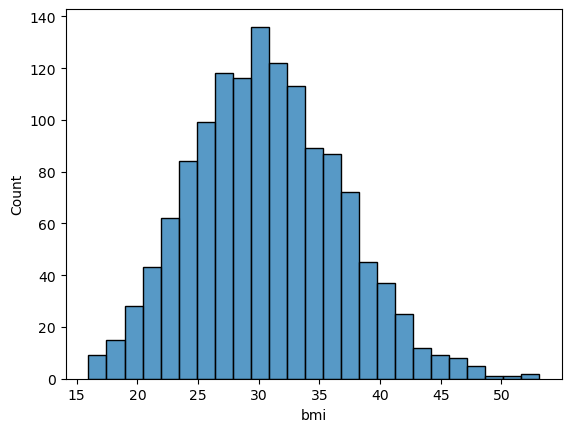

In [152]:
sns.histplot(df["bmi"])